# 8j — Preliminary composable forecast (four ways)

Implements `inst/1a_preliminary_framework_plan.md`: a joint renewal / next-generation-matrix
model driven by **age-pair contact-degree distributions**, fit for a single forecast origin
(first week of 2021, 8-week window) and scored **four ways** — the 2×2 grid of
{unweighted **NegBin**, weighted **Hurdle-Weibull**} degree models × {**Mean**, **Neighbourhood**} NGM.

Fitting uses **Pathfinder.jl** (parsimonious fit / init) and optionally **Turing NUTS** (`USE_NUTS`).
Scoring computes **WIS** via R `scoringutils` (RCall). See the spec for the modelling details and
the lean simplifications (constant within-window contacts; reduced transmission block).

In [ ]:
ENV["GKSwstype"] = "100"   # headless GR (off-screen PNG) for nbconvert
include("forecast_utils.jl")   # single preamble: base + CoMix pipeline + forecasting framework
using Random, Statistics
mkpath("../res")

USE_NUTS = false   # true ⇒ formal Turing NUTS fit (slow); false ⇒ Pathfinder parsimonious fit

## §1 Window, infection/antibody data, and age-pair degree data

In [2]:
cfg  = FrameworkConfig()
win  = WeeklyWindow(Date(2021, 1, 3); n_fit = cfg.n_fit, smax = cfg.smax, horizons = cfg.horizons)
grid = cis_age_grid()
wd    = load_window_data(win; grid = grid)
truth = load_forecast_truth(win; grid = grid)

println("origin week        : ", win.origin)
println("fit weeks          : ", win.fit_weeks[1], " … ", win.fit_weeks[end])
println("forecast targets   : ", win.forecast_weeks)
println("weekly infections @ origin (age): ", round.(wd.I_mean[:, end]; digits = 0))
println("antibody @ origin (age)         : ", round.(wd.antibody[:, end]; digits = 3))

origin week        : 2021-01-03
fit weeks          : 2020-11-15 … 2021-01-03
forecast targets   : 

[Date

("2021-01-10"), Date("2021-01-17"), Date("2021-01-24"), Date("2021-01-31")]
weekly infections @ origin (age): 

[110566.0, 59159.0, 125358.0, 121214.0, 167836.0, 161348.0, 46200.0]
antibody @ origin (age)         : [0.181, 0.219, 0.192, 0.155, 0.119, 0.123, 0.091]


In [3]:
apd    = prepare_degree_data(win, cfg; grid = grid, setting = :all)
dstats = Dict(dm => build_degree_stats(dm, apd, cfg)
              for dm in (NegBinAgePair(), HurdleWeibullAgePair()))
println("age-pair degree data built (", length(apd.weeks), " weeks × ", apd.A, "² cells).")

age-pair degree data built (12

 weeks × 7² cells).


## §2 Fit the four combinations and forecast 1–4 weeks ahead

Each combo is a full joint fit (contact-degree + infection likelihoods). The degree data is
shared across the two NGM builders; the builder changes the infection likelihood.

In [4]:
combos = [(dm, nb) for dm in (NegBinAgePair(), HurdleWeibullAgePair())
                    for nb in (MeanNGM(), NeighbourhoodDegreeNGM())]

qtabs   = DataFrame[]
fc_store = Dict{String,Array{Float64,3}}()
crps_rows = NamedTuple[]
for (dm, nb) in combos
    lbl = string(degree_label(dm), "|", ngm_label(nb))
    println("\n--- fitting ", lbl, " (USE_NUTS=", USE_NUTS, ") ---")
    res = fit_joint(dm, nb, dstats[dm], wd, cfg; use_nuts = USE_NUTS, ndraws_pf = 200)
    fc  = posterior_forecast(res.model, res.chn, wd, cfg, res.w; ndraws = cfg.n_forecast_draws)
    fc_store[lbl] = fc
    push!(qtabs, to_quantile_long(fc, truth, lbl, win, cfg, grid.LAB))
    push!(crps_rows, (model = lbl, mean_crps = mean_crps(fc, truth)))
    println("  mean native CRPS = ", round(crps_rows[end].mean_crps; digits = 1))
end
qall = vcat(qtabs...)
size(qall)


--- fitting unweighted-negbin|mean

 (USE_NUTS=false) ---
  mean native CRPS = 23424.2



--- fitting unweighted-negbin|neighbourhood (USE_NUTS=false) ---
  mean native CRPS = 

22550.2

--- fitting weighted-hweibull|mean (USE_NUTS=false) ---
  mean native CRPS = 20212.8



--- fitting weighted-hweibull|neighbourhood (USE_NUTS=false) ---


┌ Warning: 9 (0.9%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/1qXKy/src/singlepath.jl:225


  mean native CRPS = 20435.6


(2128, 8)

## §3 Score four ways — WIS via `scoringutils`

In [5]:
scores = score_wis(qall)
bymodel = sort(scores.by_model, :wis)
println("\n===== Forecasting scores, four ways (lower WIS = better) =====")
show(bymodel, allcols = true); println()
CSV.write("../res/8j_scores_by_model.csv", bymodel)
CSV.write("../res/8j_scores_by_model_horizon.csv", scores.by_model_h)
bymodel


===== Forecasting scores, four ways (lower WIS = better) =====


4×9 DataFrame
 Row │ model                            wis      overprediction  underprediction  dispersion  bias      interval_coverage_50  interval_coverage_90  ae_median 
     │ String                           Float64  Float64         Float64          Float64     Float64   Float64               Float64               Float64   
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ weighted-hweibull|mean           21208.9         14486.1          200.133     6522.71  0.646429              0.214286              0.678571    28847.4
   2 │ weighted-hweibull|neighbourhood  21454.0         16015.7          458.378     4979.89  0.639286              0.107143              0.607143    28156.6
   3 │ unweighted-negbin|neighbourhood  23656.8         17883.4          263.324     5510.14  0.682143              0.178571              0.571429    31263.4
   4 │ unweighted-negbin|mean      

Row,model,wis,overprediction,underprediction,dispersion,bias,interval_coverage_50,interval_coverage_90,ae_median
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,weighted-hweibull|mean,21208.9,14486.1,200.133,6522.71,0.646429,0.214286,0.678571,28847.4
2,weighted-hweibull|neighbourhood,21454.0,16015.7,458.378,4979.89,0.639286,0.107143,0.607143,28156.6
3,unweighted-negbin|neighbourhood,23656.8,17883.4,263.324,5510.14,0.682143,0.178571,0.571429,31263.4
4,unweighted-negbin|mean,24570.0,18535.0,199.328,5835.75,0.707143,0.214286,0.5,32418.2


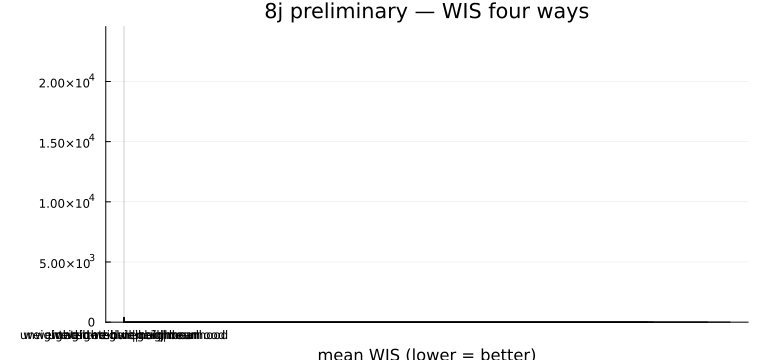

In [6]:
# WIS bar chart (four ways)
bar_lbls = bymodel.model
wis_fig = bar(bar_lbls, bymodel.wis; orientation = :h, legend = false,
              xlabel = "mean WIS (lower = better)", title = "8j preliminary — WIS four ways",
              size = (760, 360), left_margin = 8Plots.mm)
savefig(wis_fig, "../res/8j_wis_four_ways.png")
wis_fig

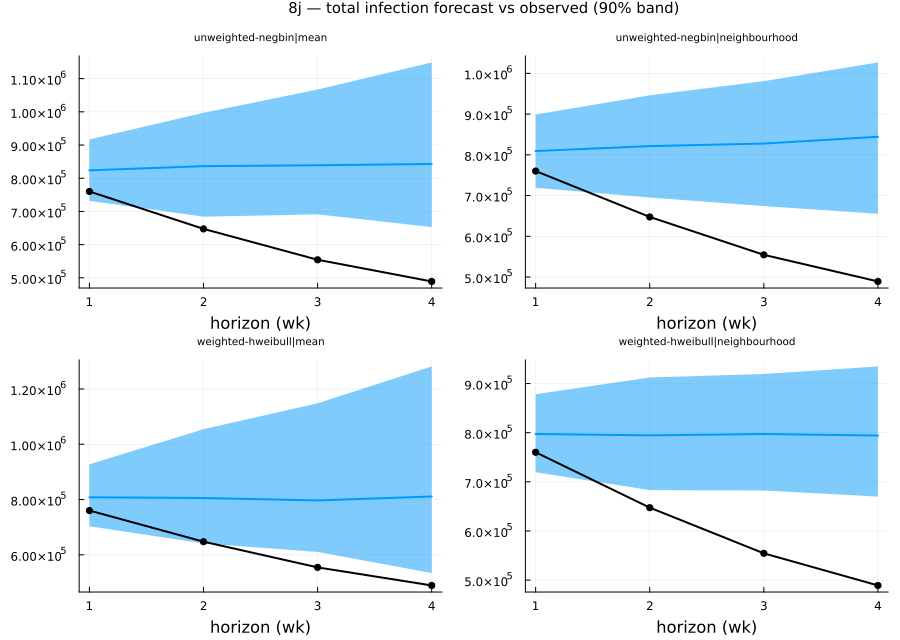

In [7]:
# Forecast fan (total infections across ages) vs realized, per combo
qs_lo, qs_hi = 0.05, 0.95
H = length(cfg.horizons)
panels = Plots.Plot[]
for (dm, nb) in combos
    lbl = string(degree_label(dm), "|", ngm_label(nb))
    fc = fc_store[lbl]
    tot = dropdims(sum(fc; dims = 1); dims = 1)          # H × draws
    med = [median(tot[h, :]) for h in 1:H]
    lo  = [quantile(tot[h, :], qs_lo) for h in 1:H]
    hi  = [quantile(tot[h, :], qs_hi) for h in 1:H]
    tr  = [sum(truth[:, h]) for h in 1:H]
    p = plot(1:H, med; ribbon = (med .- lo, hi .- med), lw = 2, label = "forecast",
             title = lbl, titlefontsize = 7, xlabel = "horizon (wk)", legend = false)
    plot!(p, 1:H, tr; lw = 2, color = :black, marker = :circle, label = "observed")
    push!(panels, p)
end
fan = plot(panels...; layout = (2, 2), size = (900, 640),
           plot_title = "8j — total infection forecast vs observed (90% band)", plot_titlefontsize = 10)
savefig(fan, "../res/8j_forecast_fan.png")
fan

## §4 Notes

- **Four ways** = the 2×2 grid; the headline table (`res/8j_scores_by_model.csv`) reports mean **WIS**,
  its overprediction/underprediction/dispersion components, bias, and 50/90% interval coverage.
- The run uses **Pathfinder** draws by default (`USE_NUTS=false`) so the notebook completes; set
  `USE_NUTS=true` for the formal Turing NUTS fit (much slower, higher-fidelity posterior).
- Lean simplifications (see spec): within-window contacts are constant per cell (RW1/GP is the swap-in
  seam); transmission block follows the reference (susceptibility + infectivity + antibody `F`), with the
  generation interval fixed at the 5-day reference. Revisit these before scientific interpretation.